# mBRSET clean dataset

This notebook shows how to read the clean mBRSET dataset, inspect labels, and display retinal fundus images.

Main tasks: diabetic retinopathy severity (`final_icdr`), edema prediction (`final_edema`), and related retinal/clinical prediction tasks.

-----

# Dataset mBRSET

Este notebook muestra cómo leer el dataset limpio mBRSET, inspeccionar las etiquetas y visualizar imágenes de fondo de ojo.

Tareas principales: predicción de severidad de retinopatía diabética usando `final_icdr`, predicción de edema usando `final_edema`, y otras tareas relacionadas con variables retinianas o clínicas.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Reemplazar con tu ruta al dataset / Replace with your path to the dataset
#DATASET_DIR = Path("PATH-TO-DATASET/mBRSET")
DATASET_DIR = Path(os.environ["SCRATCH"]) / "datasets" / "datatondatasets" / "mBRSET"

ROOT = DATASET_DIR
print("DATASET_DIR =", DATASET_DIR)

def show_image(path, title=""):
    path = Path(path)
    if not path.exists():
        print("Missing image:", path)
        return
    image = Image.open(path)
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

ROOT


DATASET_DIR = /lustre/fsn1/projects/rech/dtn/uap38od/datasets/datatondatasets/mBRSET


PosixPath('/lustre/fsn1/projects/rech/dtn/uap38od/datasets/datatondatasets/mBRSET')

In [2]:
metadata = pd.read_csv(ROOT / "metadata.csv")
print(metadata.shape)
metadata.head()


(2399, 26)


,image,split,patient,age,sex,dm_time,insulin,insulin_time,oraltreatment_dm,systemic_hypertension,...,acute_myocardial_infarction,nephropathy,neuropathy,diabetic_foot,laterality,final_artifacts,final_quality,final_icdr,final_edema,increased_cdr
0,1.1.jpg,train,1,58,1,15.0,1.0,NaN,1.0,1.0,...,1.0,1.0,0.0,0.0,right,yes,yes,4,no,no
1,1.2.jpg,train,1,58,1,15.0,1.0,NaN,1.0,1.0,...,1.0,1.0,0.0,0.0,right,yes,yes,4,no,no
2,1.3.jpg,train,1,58,1,15.0,1.0,NaN,1.0,1.0,...,1.0,1.0,0.0,0.0,left,yes,yes,4,no,no
3,1.4.jpg,train,1,58,1,15.0,1.0,NaN,1.0,1.0,...,1.0,1.0,0.0,0.0,left,yes,yes,4,no,no
4,2.1.jpg,train,2,49,1,5.0,0.0,NaN,1.0,1.0,...,0.0,0.0,0.0,0.0,right,yes,yes,0,no,no


In [3]:
print("Columns / Columnas:")
for column in metadata.columns:
    print("-", column)


Columns / Columnas:
- image
- split
- patient
- age
- sex
- dm_time
- insulin
- insulin_time
- oraltreatment_dm
- systemic_hypertension
- insurance
- educational_level
- alcohol_consumption
- smoking
- obesity
- vascular_disease
- acute_myocardial_infarction
- nephropathy
- neuropathy
- diabetic_foot
- laterality
- final_artifacts
- final_quality
- final_icdr
- final_edema
- increased_cdr


In [4]:
for column in ["split", "final_icdr", "final_edema", "increased_cdr", "sex", "laterality"]:
    if column in metadata.columns:
        print("\n", column)
        display(metadata[column].value_counts(dropna=False).to_frame("count"))



 split


,count
split,
train,1356
test,729
val,314



 final_icdr


,count
final_icdr,
0,1828
2,280
1,145
4,105
3,41



 final_edema


...

,count
increased_cdr,
no,1973
yes,421
NaN,5



 sex


,count
sex,
0,1567
1,832



 laterality


,count
laterality,
left,1206
right,1193


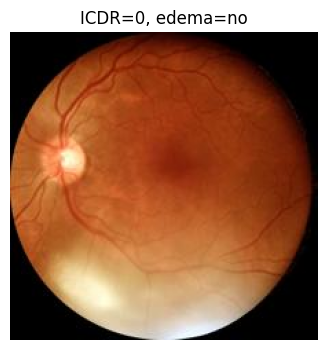

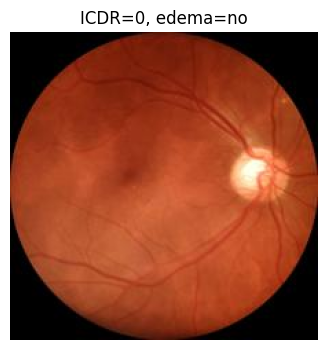

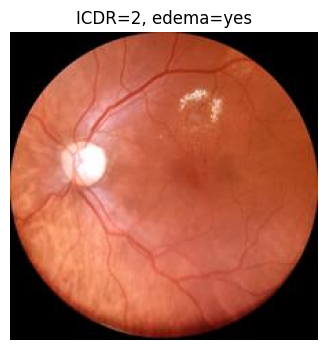

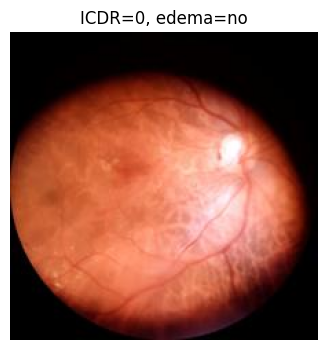

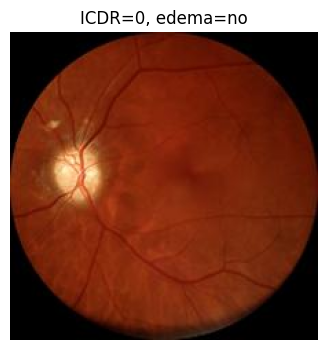

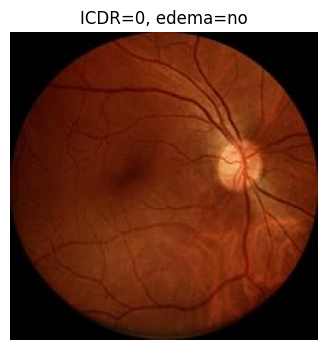

In [5]:
sample = metadata.sample(min(6, len(metadata)), random_state=1)
for _, row in sample.iterrows():
    title = f"ICDR={row.get('final_icdr', '')}, edema={row.get('final_edema', '')}"
    show_image(ROOT / "images" / row["image"], title=title)
